In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


---------------------Prework---------------------

In [2]:
df = pd.read_csv('heart.csv')


In [3]:
df.columns


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df[['Cholesterol', 'RestingBP']] = df[['Cholesterol', 'RestingBP']].replace(0,np.nan)


In [5]:
impute_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
imputer = KNNImputer(n_neighbors=5)
df[impute_cols] = imputer.fit_transform(df[impute_cols])


In [6]:
df['MaxHR_Ratio'] = df['MaxHR']/(220-df['Age'])

In [7]:
scaler = StandardScaler()
le = LabelEncoder()

In [8]:
df_normal = scaler.fit_transform(df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'MaxHR_Ratio']])

In [9]:
cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X_cat = df['ChestPainType']
X_num = df.drop(['HeartDisease', 'ChestPainType'], axis=1)
y = df['HeartDisease']
X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_num, X_cat, y, test_size=0.2, random_state=42
)
y_probs = model.predict([X_test_num, X_test_cat])
y_pred_test = (y_probs > 0.5)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


NameError: name 'y_perd_' is not defined

In [11]:
input_num = Input(shape=(X_train_num.shape[1],), name='input_numeric')
input_cat = Input(shape=(1,), name='input_category')
embedding = Embedding(input_dim=4, output_dim=3, name='embedding_layer')(input_cat)
flatten = Flatten()(embedding)
merged = Concatenate()([input_num, flatten])


In [12]:
x = Dense(64, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(16, activation='relu')(x)


In [13]:
output = Dense(1, activation='sigmoid', name='output')(x)
model = Model(inputs=[input_num, input_cat], outputs=output)
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy', 'AUC'])

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_category      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 1, 3)      │         12 │ input_category[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numeric       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3)         │          0 │ embedding_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14)        │          0 │ input_numeric[0]… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        960 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │         36 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        320 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ batch_normalizat

 Total params: 7,465 (29.16 KB)

 Trainable params: 7,081 (27.66 KB)

 Non-trainable params: 384 (1.50 KB)

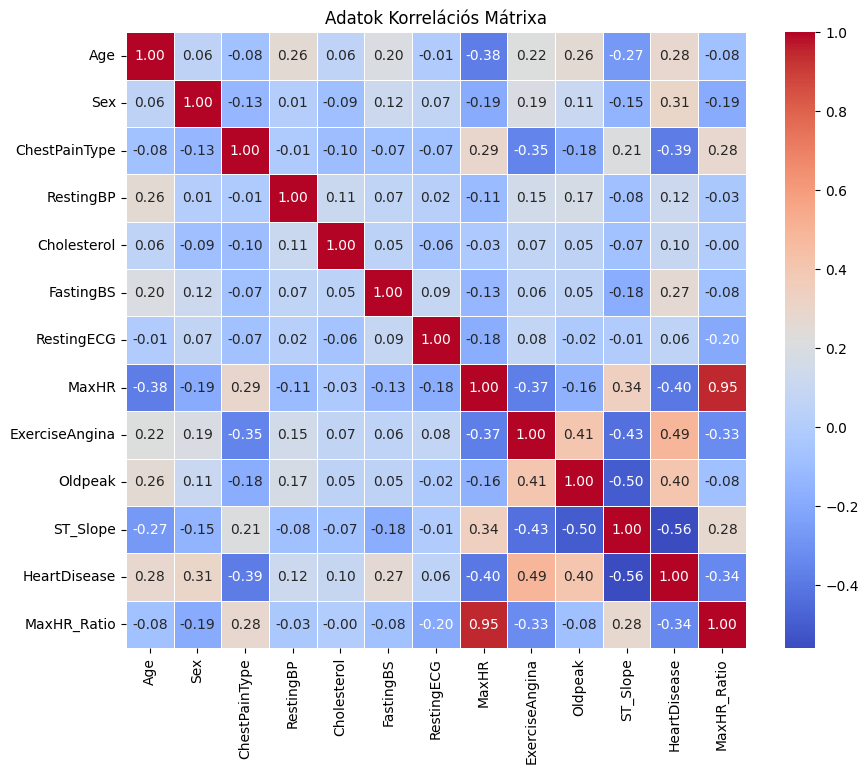

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Adatok Korrelációs Mátrixa')
plt.show()



In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [25]:
history = model.fit(
    x=[X_train_num, X_train_cat],
    y=y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.8764 - accuracy: 0.8177 - loss: 0.4379 - val_AUC: 0.8688 - val_accuracy: 0.8163 - val_loss: 0.4894
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.8772 - accuracy: 0.8041 - loss: 0.4335 - val_AUC: 0.8663 - val_accuracy: 0.7551 - val_loss: 0.6047
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.8840 - accuracy: 0.8177 - loss: 0.4231 - val_AUC: 0.8604 - val_accuracy: 0.7143 - val_loss: 0.7148
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8854 - accuracy: 0.8262 - loss: 0.4231 - val_AUC: 0.8616 - val_accuracy: 0.7347 - val_loss: 0.6326
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8768 - accuracy: 0.8160 - loss: 0.4384 - val_AUC: 0.8745 - val_accuracy: 0.8163 - val_loss: 0.4464
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8743 - accuracy: 0.7922 - loss: 0.4408 - val_AUC: 0.8694 - val_accuracy: 0.8095 - val_loss: 0.4963
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

In [24]:
test_loss, test_auc, test_accuracy = model.evaluate([X_test_num, X_test_cat], y_test)
print(f"Teszt Loss: {test_loss}")
print(f"Teszt Accuracy: {test_accuracy}")
print(f"Teszt AUC: {test_auc}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.8962 - accuracy: 0.8043 - loss: 0.4879
Teszt Loss: 0.487939715385437
Teszt Accuracy: 0.8962252736091614
Teszt AUC: 0.804347813129425


------------------------------------Vizualization------------------------------------

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


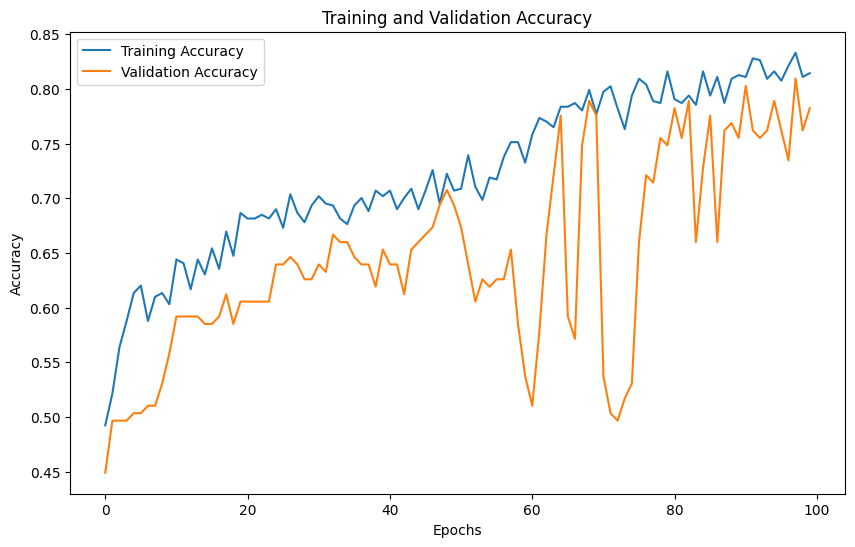

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


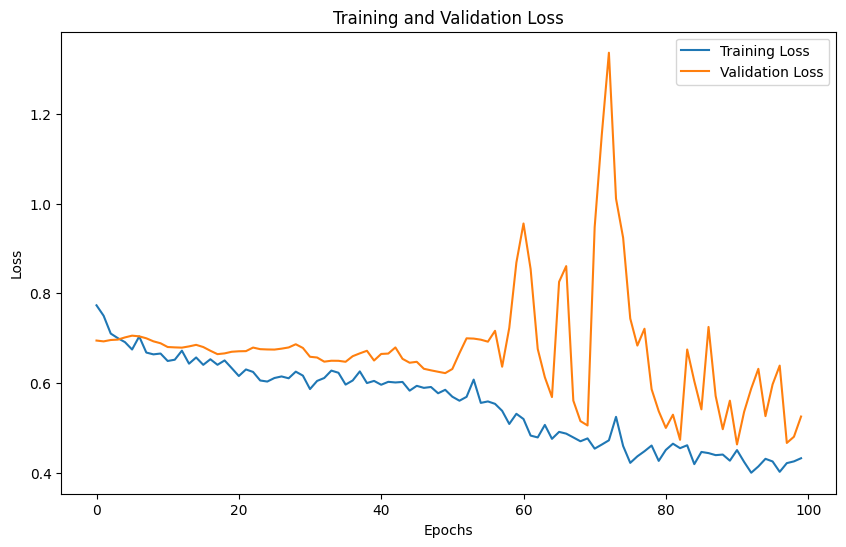

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


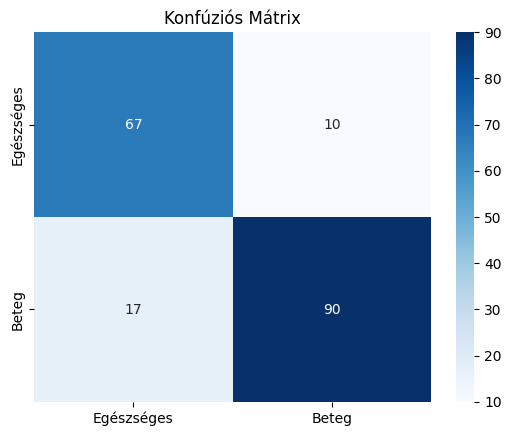

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Egészséges', 'Beteg'],
            yticklabels=['Egészséges', 'Beteg'])
plt.title('Konfúziós Mátrix')
plt.grid(False) 
plt.show()


In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=['Egészséges', 'Beteg'], 
                                        cmap='Blues')